# Alpha aggregating Setup

Load the working alpha functions from `Factors.ipynb`, load only required data inputs from `data/alpha_inputs`, and build one `alphas` dictionary.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

import sys


# add repo root to sys.path
repo_root = Path.cwd().parents[0]  # adjust if needed
  # if you're running from repo root
sys.path.insert(0, str(repo_root))

from notebooks.operators_library import (
    ts_mean,
    ts_av_diff,
    ts_std_dev,
    ts_sum,
    ts_zscore,
    zscore,
    rank,
    ts_rank,
    signed_power,
    bucket,
    densify,
    ts_delay,
    group_neutralize,
    scale,
    trade_when,
    trade_when_hold,
    hump,
    vector_neut,
    group_mean,
    quantile_cauchy,
    ts_quantile_cauchy,
    ts_regression,
    ts_step,
    group_rank,
    winsorize,
    ts_backfill,
    ts_arg_min,
    ts_decay_linear,
    if_else,
    group_scale,
    days_from_last_change,
)

if (Path.cwd() / "notebooks").exists():
    repo_root = Path.cwd()
elif (Path.cwd().parent / "notebooks").exists():
    repo_root = Path.cwd().parent
else:
    raise FileNotFoundError("Could not locate repo root containing notebooks/.")


In [3]:
WORKING_ALPHA_ORDER = [
    "alpha_0413a",
    "alpha_0615a",
    "alpha_0403c",
    "alpha_0812a",
    "alpha_0407a",
    "alpha_0612d",
    "alpha_0503b",
    "alpha_0412",
    "alpha_0418b",
    "alpha_0505",
    "alpha_0404b",
    "alpha_0618e",
    "alpha_0413b",
    "alpha_0810a",
    "alpha_0415b",
    "alpha_0617a",
    "alpha_0604c",
    "alpha_0616a",
]

factors_nb_path = repo_root / "notebooks" / "Factors.ipynb"
factors_nb = json.loads(factors_nb_path.read_text(encoding="utf-8"))

loaded_alpha_names = []
for cell in factors_nb.get("cells", []):
    if cell.get("cell_type") != "code":
        continue
    src = "".join(cell.get("source", []))
    stripped = src.strip()
    if not stripped.startswith("def alpha_"):
        continue
    alpha_name = stripped.split("def ")[1].split("(")[0].strip()
    if alpha_name not in WORKING_ALPHA_ORDER:
        continue

    exec(src, globals())
    loaded_alpha_names.append(alpha_name)

missing_alpha_defs = sorted(set(WORKING_ALPHA_ORDER) - set(loaded_alpha_names))
if missing_alpha_defs:
    raise ValueError(f"Missing alpha definitions in Factors.ipynb: {missing_alpha_defs}")

print(f"Loaded {len(loaded_alpha_names)} alpha functions from {factors_nb_path.name}.")


Loaded 18 alpha functions from Factors.ipynb.


In [4]:
ALPHA_INPUTS = {
    "alpha_0413a": ("close_df", "high_df", "low_df"),
    "alpha_0615a": ("volume_df", "sharesout_df", "cap_df"),
    "alpha_0403c": ("volume_df", "sharesout_df"),
    "alpha_0812a": ("liabilities_df", "assets_df", "debt_df", "equity_df"),
    "alpha_0407a": ("debt_df",),
    "alpha_0612d": ("debt_df", "assets_df", "volume_df"),
    "alpha_0503b": ("sharesout_df", "volume_df", "vwap_df", "low_df", "open_df", "high_df"),
    "alpha_0412": ("operating_income_df", "vwap_df", "volume_df", "returns_df"),
    "alpha_0418b": ("operating_income_df", "vwap_df"),
    "alpha_0505": ("operating_income_df", "vwap_df"),
    "alpha_0404b": ("returns_df", "operating_income_df", "cap_df"),
    "alpha_0618e": ("vwap_df", "close_df", "volume_df"),
    "alpha_0413b": ("operating_income_df", "cap_df"),
    "alpha_0810a": ("returns_df", "cap_df", "volume_df"),
    "alpha_0415b": ("close_df", "volume_df"),
    "alpha_0617a": ("open_df", "volume_df"),
    "alpha_0604c": ("close_df", "high_df", "low_df"),
    "alpha_0616a": ("close_df", "open_df", "volume_df"),
}

manifest_path = repo_root / "notebooks" / "data" / "alpha_inputs" / "manifest.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
manifest_files = manifest.get("files", {})

required_data_names = sorted({name for items in ALPHA_INPUTS.values() for name in items})
data = {}
for data_name in required_data_names:
    rel_path = manifest_files.get(data_name)
    if rel_path is None:
        rel_path = f"data/alpha_inputs/{data_name}.parquet"
    file_path = (repo_root / "notebooks" / rel_path).resolve()
    data[data_name] = pd.read_parquet(file_path)

globals().update(data)
print(f"Loaded {len(data)} input dataframes from {manifest_path.parent}.")


Loaded 14 input dataframes from c:\Users\danie\Python\CapitOx\Multi-Factor-Equities-Investing\notebooks\data\alpha_inputs.


In [5]:
alpha_functions = {name: globals()[name] for name in WORKING_ALPHA_ORDER}

alphas = {
    alpha_name: alpha_functions[alpha_name](
        *[data[input_name] for input_name in ALPHA_INPUTS[alpha_name]]
    )
    for alpha_name in WORKING_ALPHA_ORDER
}

print(f"Built alpha dictionary with {len(alphas)} alphas.")
print(list(alphas.keys()))


c:\Users\danie\Python\CapitOx\Multi-Factor-Equities-Investing\notebooks\operators_library.py:140: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cond = cond_df.reindex(val_df.index).fillna(False).astype(bool)
c:\Users\danie\Python\CapitOx\Multi-Factor-Equities-Investing\notebooks\operators_library.py:140: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cond = cond_df.reindex(val_df.index).fillna(False).astype(bool)


Built alpha dictionary with 18 alphas.
['alpha_0413a', 'alpha_0615a', 'alpha_0403c', 'alpha_0812a', 'alpha_0407a', 'alpha_0612d', 'alpha_0503b', 'alpha_0412', 'alpha_0418b', 'alpha_0505', 'alpha_0404b', 'alpha_0618e', 'alpha_0413b', 'alpha_0810a', 'alpha_0415b', 'alpha_0617a', 'alpha_0604c', 'alpha_0616a']


In [28]:
def winsorize_cross_section(signals: pd.DataFrame, lower: float = 0.01, upper: float = 0.01) -> pd.DataFrame:
    if signals.empty:
        return signals.copy()

    lo_q = lower
    hi_q = 1.0 - upper

    # quantiles (Series indexed by date)
    lo = signals.quantile(lo_q, axis=1)
    hi = signals.quantile(hi_q, axis=1)

    # broadcast thresholds to matrix
    lo_b = lo.to_numpy(dtype=float)[:, None]  # (T,1)
    hi_b = hi.to_numpy(dtype=float)[:, None]  # (T,1)

    # IMPORTANT: convert DataFrame to float ndarray, turning pd.NA -> np.nan
    vals = signals.to_numpy(dtype=float)

    # masks: True where threshold exists for that row
    mask_lo = ~np.isnan(lo_b)
    mask_hi = ~np.isnan(hi_b)

    vals = np.where(mask_lo, np.maximum(vals, lo_b), vals)
    vals = np.where(mask_hi, np.minimum(vals, hi_b), vals)

    return pd.DataFrame(vals, index=signals.index, columns=signals.columns)


def standardize_cross_section(signals: pd.DataFrame) -> pd.DataFrame:
    mu = signals.mean(axis=1)
    sigma = signals.std(axis=1, ddof=0).replace(0.0, np.nan)
    return signals.sub(mu, axis=0).div(sigma, axis=0)

def normalize_weights(
        z_signals: pd.DataFrame
) -> pd.DataFrame:
    abs_sum = z_signals.abs().sum(axis=1).replace(0.0, np.nan)
    return z_signals.div(abs_sum, axis=0).fillna(0.0)

def signals_to_weights(
        signals: pd.DataFrame, 
        lower: float = 0.01,
        upper: float = 0.01,
) -> pd.DataFrame:
    s= winsorize_cross_section(signals, lower, upper)
    z = standardize_cross_section(s)
    w = normalize_weights(z)
    return w

In [29]:
def alpha_return_series(
        weights: pd.DataFrame,
        forward_returns: pd.DataFrame,
) -> pd.Series:
    """
    R_k,(t+1) = sum_i w_i,t * r_i,(t+1)
    note already shifted returns
    """
    return (weights * forward_returns.reindex_like(weights)).sum(axis=1)

In [31]:
from typing import Dict, Tuple
def build_all_alpha_returns(
        signals: Dict[str, pd.DataFrame],
        forwards_return: pd.DataFrame,
        lower: float = 0.01,
        upper: float = 0.01,
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    alpha_returns: Dict[str, pd.Series] = {}
    all_weights = {}

    for name, sig in signals.items():
        w = signals_to_weights(sig, lower, upper)
        all_weights[name] = w
        alpha_returns[name] = alpha_return_series(w, forwards_return)
    alpha_returns_df = pd.DataFrame(alpha_returns)
    return alpha_returns_df, all_weights


In [36]:
fwd_returns = data['close_df'].pct_change().shift(-1)   
fwd_returns = fwd_returns.iloc[:-1,:]
fwd_returns.head()

C:\Users\danie\AppData\Local\Temp\ipykernel_45716\543741967.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd_returns = data['close_df'].pct_change().shift(-1)


Price Close,ENR1n.DE,ENI.MI,ENEI.MI,RACE.MI,DHLn.DE,ALVG.DE,IBE.MC,DTEGn.DE,SASY.PA,LVMH.PA,...,DB1Gn.DE,INGA.AS,PRX.AS,OREP.PA,TTEF.PA,ABI.BR,AXAF.PA,ASML.AS,BAYGn.DE,CRDI.MI
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-30,<NA>,<NA>,<NA>,<NA>,0.000555,-0.004732,<NA>,-0.004906,<NA>,<NA>,...,0.000507,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,<NA>
2015-01-02,<NA>,-0.083619,-0.064674,<NA>,-0.035107,-0.024506,-0.018049,-0.030717,-0.028765,-0.029041,...,-0.002025,-0.046083,<NA>,-0.023654,-0.059847,-0.022342,-0.037173,-0.0184,-0.033628,-0.066237
2015-01-05,<NA>,0.013463,0.014526,<NA>,0.005745,0.001125,-0.004004,-0.011737,0.003276,-0.011413,...,-0.004735,0.0,<NA>,0.0,-0.001501,-0.009936,-0.010875,-0.032232,0.011447,-0.013793
2015-01-06,<NA>,0.005166,-0.001718,<NA>,0.001904,0.009363,-0.001279,0.028504,0.010611,0.000796,...,0.024469,0.007246,<NA>,0.005591,0.02267,0.024309,0.01072,0.003307,0.0,-0.00979
2015-01-07,<NA>,0.038913,0.045324,<NA>,0.021855,0.026345,0.019759,0.049269,0.042132,0.031424,...,0.028363,0.033573,<NA>,0.036323,0.038579,0.049532,0.041338,0.03814,0.054323,0.048224


In [37]:
alpha_returns_df, all_weights = build_all_alpha_returns(alphas, fwd_returns)

In [40]:
alpha_returns_df.head()

,alpha_0413a,alpha_0615a,alpha_0403c,alpha_0812a,alpha_0407a,alpha_0612d,alpha_0503b,alpha_0412,alpha_0418b,alpha_0505,alpha_0404b,alpha_0618e,alpha_0413b,alpha_0810a,alpha_0415b,alpha_0617a,alpha_0604c,alpha_0616a
Date,,,,,,,,,,,,,,,,,,
2014-12-30,0.002422,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,0.0,0.0,0.0,0.0,0.0,<NA>,0.0,0.0,0.0,0.0
2015-01-01,<NA>,<NA>,0.0,<NA>,<NA>,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,0.0,<NA>,<NA>,0.0,0.0,<NA>,0.0
2015-01-02,0.006572,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005026,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-05,-0.004594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.001056,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-06,0.000174,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.001754,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
import matplotlib.pyplot as plt
# Plot Equity Backtest Curve
def plot_equity_curve(pnl: pd.Series, title: str = "Equity Curve"):
    pnl = pnl.replace([np.inf, -np.inf], np.nan).dropna()

    # trim leading zeros
    non_zero = pnl != 0
    if non_zero.any():
        first_idx = pnl[non_zero].index[0]
        pnl = pnl.loc[first_idx:]
        
    equity = (1 + pnl).cumprod()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(equity.index, equity.values)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Equity (start = 1.0)")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

def performance_summary(pnl: pd.Series, periods_per_year: int = 252):
    pnl = pnl.dropna()
    # Skip the Training Period
    non_zero = pnl != 0
    if non_zero.any():
        first_idx = pnl[non_zero].index[0]
        pnl = pnl.loc[first_idx:]

    n = len(pnl)

    # cumulative equity (start at 1.0)
    equity = (1 + pnl).cumprod()
    # total return
    total_return = equity.iloc[-1] - 1.0

    # CAGR
    years = n / periods_per_year
    if years > 0:
        cagr = equity.iloc[-1] ** (1 / years) - 1
    else:
        cagr = np.nan

    # annualized volatility
    ann_vol = pnl.std(ddof=1) * np.sqrt(periods_per_year)

    # Sharpe
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan

    # drawdowns
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()

    # Calmar
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    # hit rate
    hit_rate = (pnl > 0).mean()

    print("===== Performance Summary =====")
    print(f"Periods             : {n}")
    print(f"Total Return        : {total_return:8.2%}")
    print(f"CAGR                : {cagr:8.2%}")
    print(f"Ann. Volatility     : {ann_vol:8.2%}")
    print(f"Sharpe Ratio        : {sharpe:8.2f}")
    print(f"Max Drawdown        : {max_dd:8.2%}")
    print(f"Calmar Ratio        : {calmar:8.2f}")
    print(f"Hit Rate (p>0)      : {hit_rate:8.2%}")

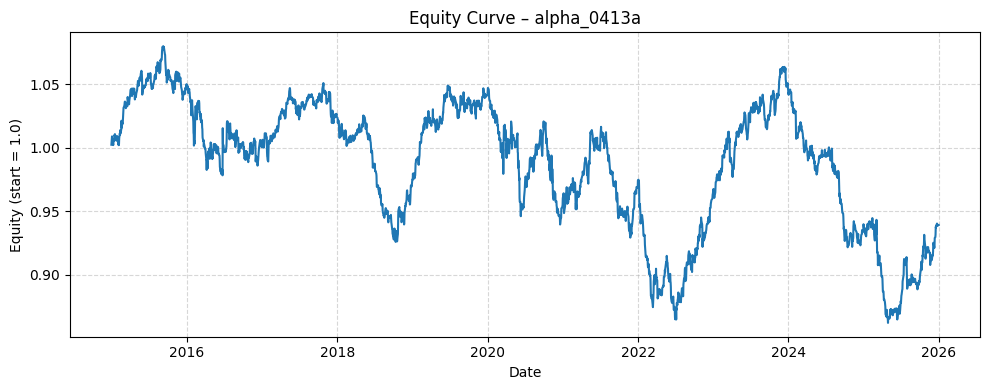

===== Performance Summary =====
Periods             : 2817
Total Return        :   -6.07%
CAGR                :   -0.56%
Ann. Volatility     :    5.66%
Sharpe Ratio        :    -0.10
Max Drawdown        :  -20.18%
Calmar Ratio        :    -0.03
Hit Rate (p>0)      :   50.76%


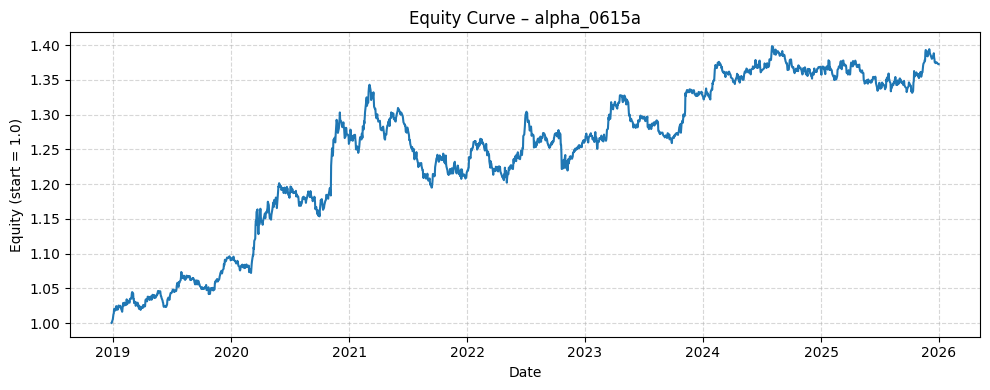

===== Performance Summary =====
Periods             : 1796
Total Return        :   37.25%
CAGR                :    4.54%
Ann. Volatility     :    6.04%
Sharpe Ratio        :     0.75
Max Drawdown        :  -11.02%
Calmar Ratio        :     0.41
Hit Rate (p>0)      :   50.45%


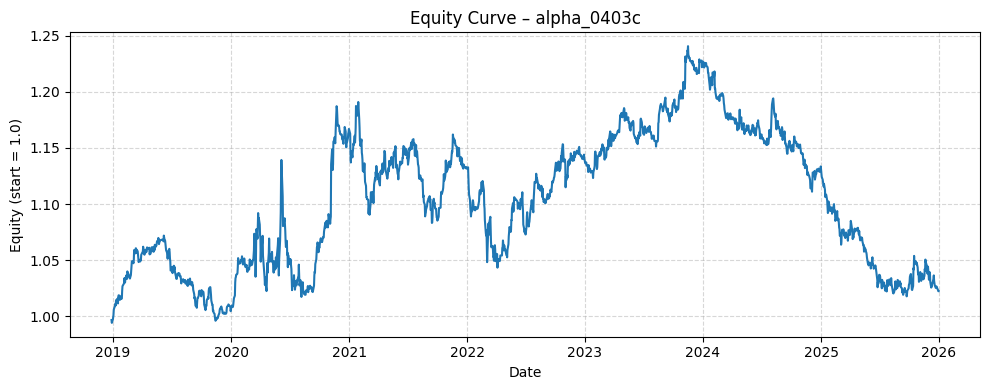

===== Performance Summary =====
Periods             : 1796
Total Return        :    2.23%
CAGR                :    0.31%
Ann. Volatility     :    7.34%
Sharpe Ratio        :     0.04
Max Drawdown        :  -17.98%
Calmar Ratio        :     0.02
Hit Rate (p>0)      :   49.78%


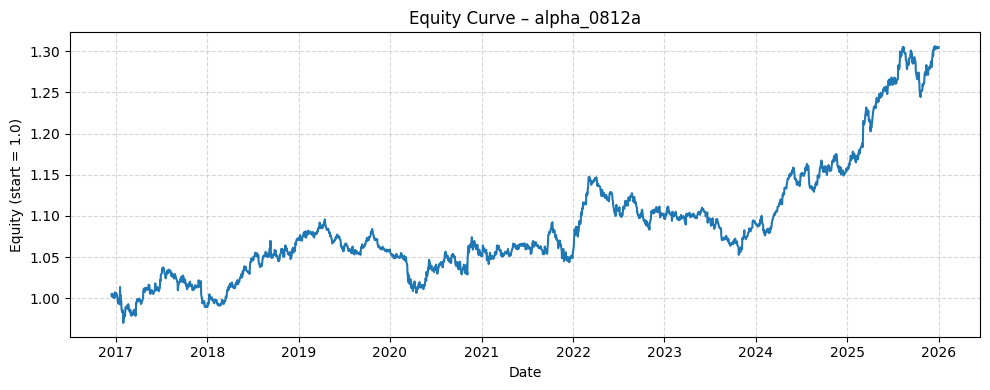

===== Performance Summary =====
Periods             : 2314
Total Return        :   30.41%
CAGR                :    2.93%
Ann. Volatility     :    4.54%
Sharpe Ratio        :     0.65
Max Drawdown        :   -8.26%
Calmar Ratio        :     0.35
Hit Rate (p>0)      :   51.30%


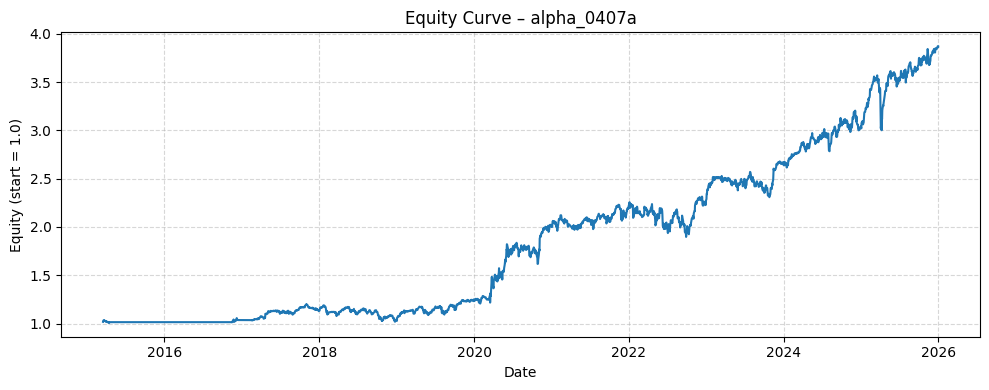

===== Performance Summary =====
Periods             : 2764
Total Return        :  286.76%
CAGR                :   13.12%
Ann. Volatility     :   14.38%
Sharpe Ratio        :     0.91
Max Drawdown        :  -15.92%
Calmar Ratio        :     0.82
Hit Rate (p>0)      :   45.55%


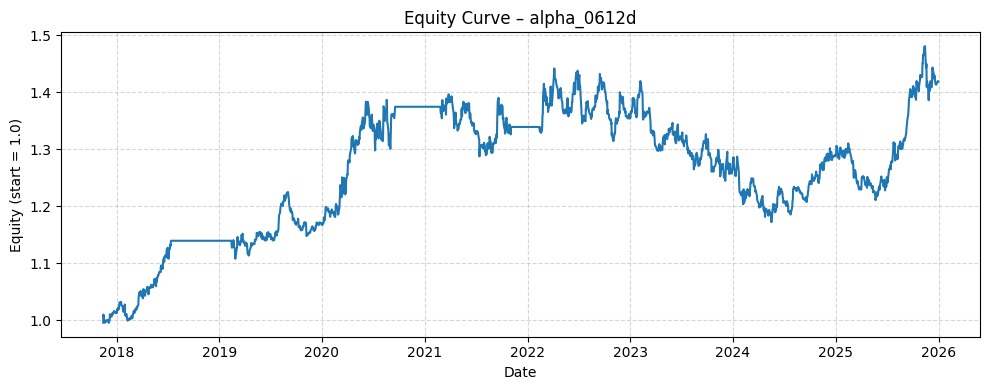

===== Performance Summary =====
Periods             : 2080
Total Return        :   41.87%
CAGR                :    4.33%
Ann. Volatility     :    8.62%
Sharpe Ratio        :     0.50
Max Drawdown        :  -18.71%
Calmar Ratio        :     0.23
Hit Rate (p>0)      :   42.84%


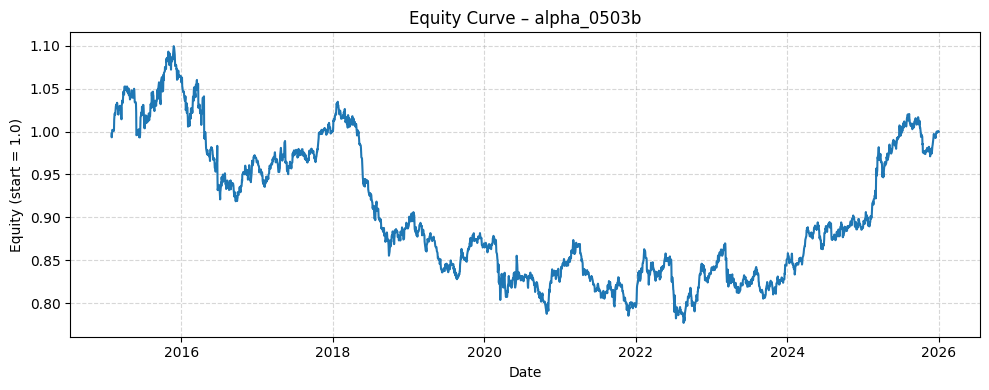

===== Performance Summary =====
Periods             : 2811
Total Return        :   -0.04%
CAGR                :   -0.00%
Ann. Volatility     :    7.24%
Sharpe Ratio        :    -0.00
Max Drawdown        :  -29.36%
Calmar Ratio        :    -0.00
Hit Rate (p>0)      :   50.02%


In [48]:
for name in alpha_returns_df.columns[:7]:
    plot_equity_curve(
        alpha_returns_df[name],
        title=f"Equity Curve – {name}"
    )
    performance_summary(alpha_returns_df[name])